In [ ]:
# Step 1: Install required dependencies
# In Google Colab, we use !pip to install packages from the command line. If you are building this on your computer just use pip
# pyxdf is used for reading XDF files
!pip install mne pyxdf h5io

Number of streams found: 2
Stream type: eeg
<Info | 7 non-empty values
 bads: []
 ch_names: EEG 1, EEG 2, EEG 3, EEG 4, EEG 5, EEG 6, EEG 7, EEG 8
 chs: 8 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 250.0 Hz
>
Channels: ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8']
Duration: 2187.6 seconds
Using matplotlib as 2D backend.


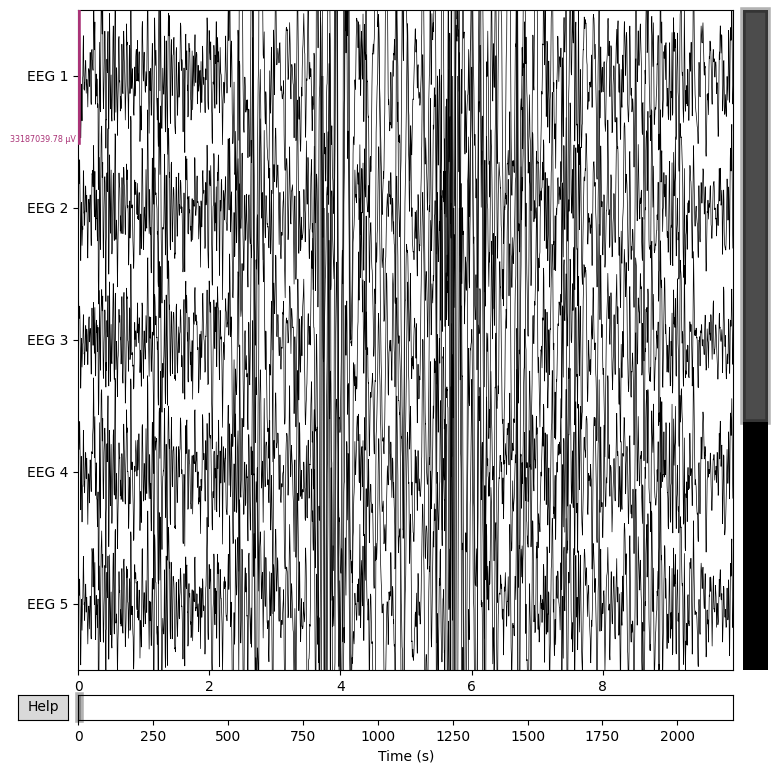

In [ ]:
# Step 2: Import necessary modules
import mne
import matplotlib.pyplot as plt
import pyxdf
import numpy as np

# Step 3: Provide the XDF file path
xdf_filepath = '/sub-P001_ses-S001_task-Default_run-001_eeg.xdf'

# Step 4: Load XDF file
streams, header = pyxdf.load_xdf(xdf_filepath)

print(f"Number of streams found: {len(streams)}")

# ---- Find EEG stream safely ----
eeg_stream = None
for stream in streams:
    stream_type = stream["info"]["type"][0].lower()
    print("Stream type:", stream_type)
    if "eeg" in stream_type:
        eeg_stream = stream
        break

# ---- Convert to NumPy array BEFORE transpose ----
data = np.array(eeg_stream["time_series"])

# Check orientation (samples x channels is typical for XDF)
if data.shape[0] > data.shape[1]:
    data = data.T   # make it channels x samples for MNE

# ---- Sampling rate ----
sfreq = float(eeg_stream["info"]["nominal_srate"][0])

# ---- Channel names ----
n_channels = data.shape[0]

# Try to read channel labels from XDF
try:
    ch_names = [
        ch["label"][0]
        for ch in eeg_stream["info"]["desc"][0]["channels"][0]["channel"]
    ]
except Exception:
    ch_names = [f"EEG {i+1}" for i in range(n_channels)]

# ---- Channel types (assume all EEG) ----
ch_types = ['eeg'] * n_channels

# ---- Create MNE info ----
info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=ch_types
)

# ---- Create Raw object ----
raw = mne.io.RawArray(data, info, verbose=False)

print(raw.info)
print(f"Channels: {raw.ch_names}")
print(f"Duration: {raw.times[-1]:.1f} seconds")

# ---- Plot ----
raw.plot(
    duration=10,
    n_channels=min(5, n_channels),
    scalings='auto',
    title='Raw EEG Data'
)

plt.show()

In [ ]:
# Step 2: Import necessary modules
# We import mne for data handling and plotting.
import mne
import matplotlib.pyplot as plt
import pyxdf

In [ ]:
# Step 3: Provide the XDF file path
# Replace 'your_file.xdf' with the actual path to your XDF file.
# In Colab, you can upload files via the left sidebar (Files > Upload).
xdf_filepath = '/sub-P001_ses-S001_task-Default_run-001_eeg.xdf'
#FOR DEMONSTRATION PURPOSES i will use MNE's built-in sample XDF data (DO NOT DO THIS FOR YOUR PROJECT!! use ur own data)
from mne.datasets import misc

misc_data_path = misc.data_path()

# Overwriting xdf_filepath with mne demo sample
#xdf_filepath = misc_data_path / "xdf" / "sub-P001_ses-S004_task-Default_run-001_eeg_a2.xdf"

In [ ]:
#Step 4: Load data into MNE

streams, header = pyxdf.load_xdf(xdf_filepath)

# Usually the first stream (index 0) is the EEG data stream
# Inspect streams to confirm (print(streams) or len(streams))
print(streams)
eeg_stream = streams[0]  # change index if your EEG is in another stream

# Extract data (channels x time) and sampling frequency
data = eeg_stream["time_series"].T          # transpose so channels first
sfreq = float(eeg_stream["info"]["nominal_srate"][0])

# Create channel names (fallback if not present)
n_channels = data.shape[0]
ch_names = [f"EEG {i+1}" for i in range(n_channels - 1)] + ["STI 014"]  # last = stim/marker if present

# Create info object (all channels as EEG except last as stim if applicable)
ch_types = ['eeg'] * (n_channels - 1) + ['stim']   # adjust based on your file

# Create the MNE info object (basically assigning the data some metadata for MNE's reference)
info = mne.create_info(ch_names=ch_names,
                       sfreq=sfreq,
                       ch_types=ch_types)

# Create the Raw object
raw = mne.io.RawArray(data, info, verbose=False)

# Optional: Add annotations from marker stream if you have one
# if len(streams) > 1 and streams[1]["info"]["type"][0] == "Markers":
#     markers = streams[1]
#     # convert marker times & descriptions - MNE Annotations
#     # (see MNE docs or MNELAB examples for full code)

print(raw.info)
print(f"Channels: {raw.ch_names}")
print(f"Duration: {raw.times[-1]:.1f} seconds")

[{'info': defaultdict(<class 'list'>, {'name': ['obci_eeg1'], 'type': ['EEG'], 'channel_count': ['8'], 'nominal_srate': ['250'], 'channel_format': ['float32'], 'source_id': ['openbcigui'], 'version': ['1.1000000000000001'], 'created_at': ['53790.569651700003'], 'uid': ['e0f75d1f-c01b-492e-8719-eeccb3c97ffe'], 'session_id': ['default'], 'hostname': ['LAPTOP-5MFRK418'], 'v4address': [None], 'v4data_port': ['16572'], 'v4service_port': ['16572'], 'v6address': [None], 'v6data_port': ['16572'], 'v6service_port': ['16572'], 'desc': [None], 'stream_id': 2, 'effective_srate': np.float64(250.25530821819325), 'segments': [(0, 546889)], 'clock_segments': [(0, 546889)]}), 'footer': {'info': defaultdict(<class 'list'>, {'first_timestamp': ['53861.9738242'], 'last_timestamp': ['56047.27968400001'], 'sample_count': ['546890'], 'clock_offsets': [defaultdict(<class 'list'>, {'offset': [defaultdict(<class 'list'>, {'time': ['53867.6499512'], 'value': ['-2.369999856455252e-05']}), defaultdict(<class 'list

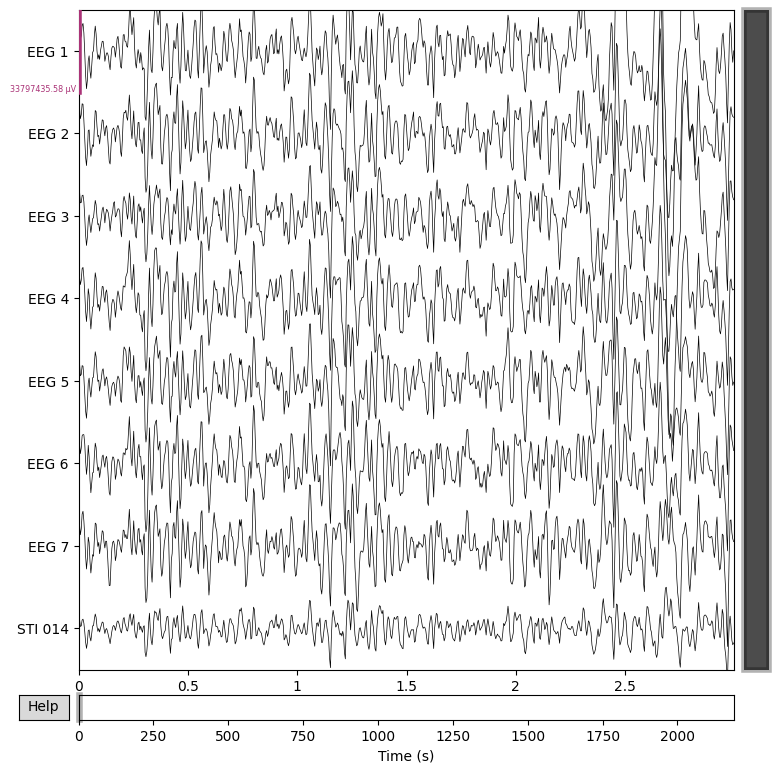

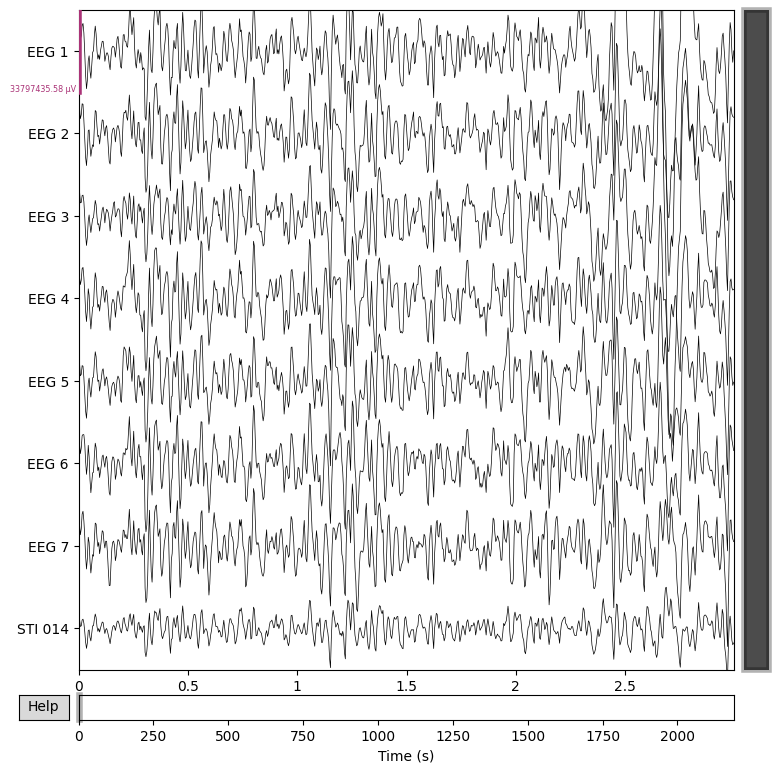

In [ ]:
# Step 5: Plot the raw (unfiltered) data
# raw.plot() creates an interactive plot showing all channels over time.
# You can zoom, scroll, and select channels in the plot.
# duration=10 shows 10 seconds of data at a time.
# n_channels=5 shows 5 channels at once (adjust based on your data).

# Plot raw data
raw.plot(
    duration=3,               # initial time window (seconds)
    n_channels=8,              # how many channels to show initially
    scalings='auto',           # auto vertical scaling per channel
    title='Raw EEG Data',
    show_scrollbars=True,      # try to show them
    show_scalebars=True,       # shows microV / unit scale bars
)


In [ ]:
# Step 6: Apply a filter to the data
# Here, we apply a bandpass filter (e.g., 1-40 Hz) to remove noise outside this range.
# This is common for EEG: low_freq removes slow drifts, high_freq removes high-frequency noise.
# We create a copy of the raw data to keep the original intact.
filtered_raw = raw.copy().filter(l_freq=1, h_freq=40, fir_design='firwin')
notch_raw = filtered_raw.notch_filter(freqs=50)
band_pass_filtered = notch_raw.filter(l_freq=6, h_freq=17)
first_band_pass = band_pass_filtered.copy().filter(l_freq=6, h_freq=8)
second_band_pass = band_pass_filtered.copy().filter(l_freq=10, h_freq=12)
third_band_pass = band_pass_filtered.copy().filter(l_freq=12, h_freq=14)
fourth_band_pass = band_pass_filtered.copy().filter(l_freq=16, h_freq=18)
eyes_closed_band_pass = band_pass_filtered.copy().filter(l_freq=8, h_freq=12)
# Print info about the filtered data (optional)
#print(band_pass_filtered.info, first_band_pass.info, second_band_pass.info, third_band_pass.info, fourth_band_pass.info)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  band_pass_filtered.compute_psd().plot()


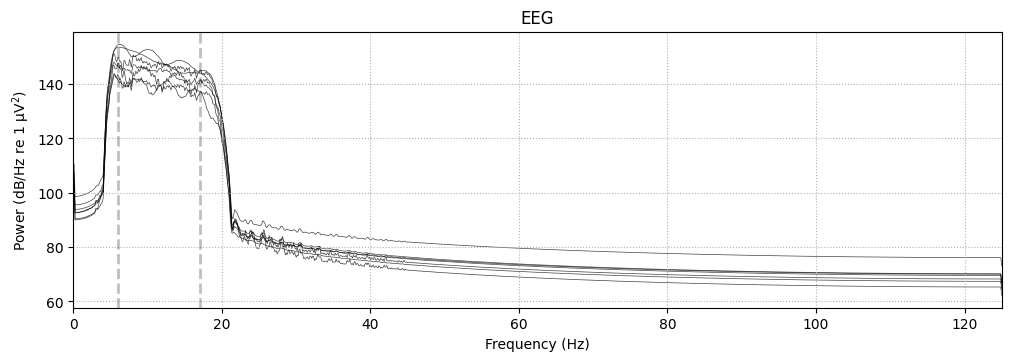

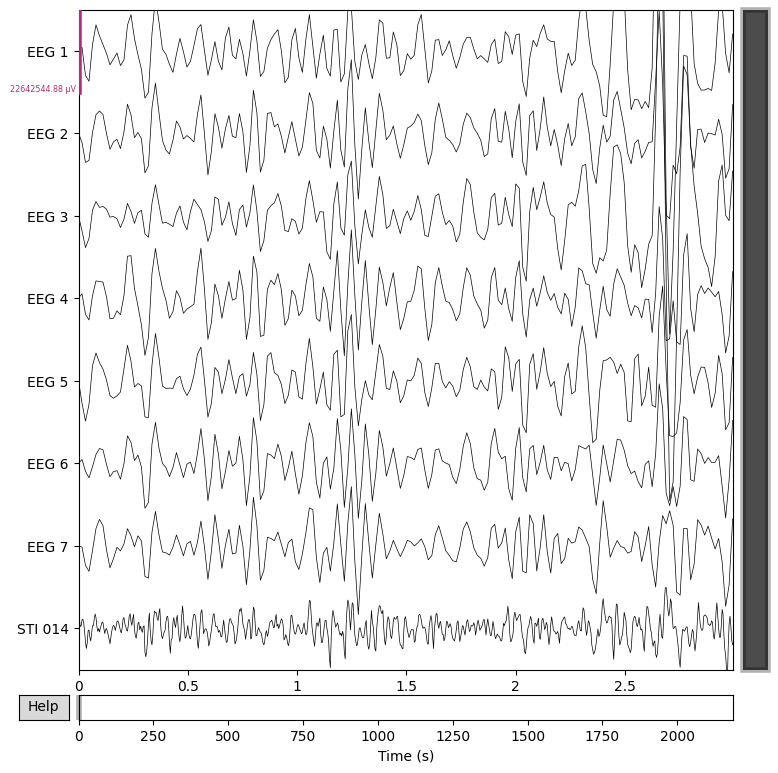

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:10: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  first_band_pass.compute_psd().plot()


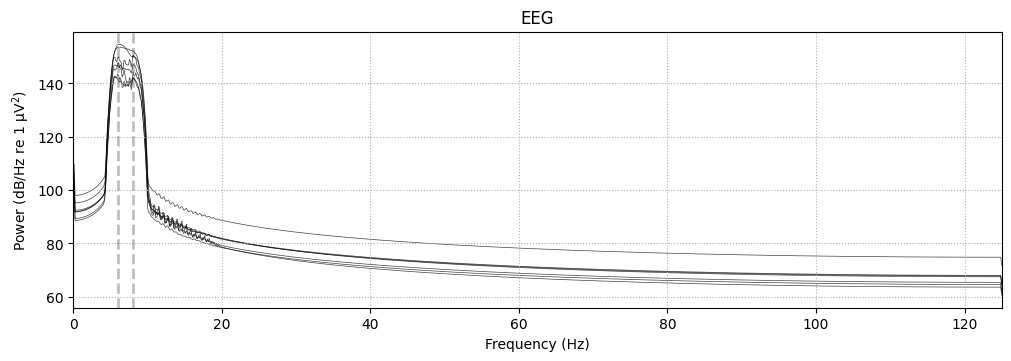

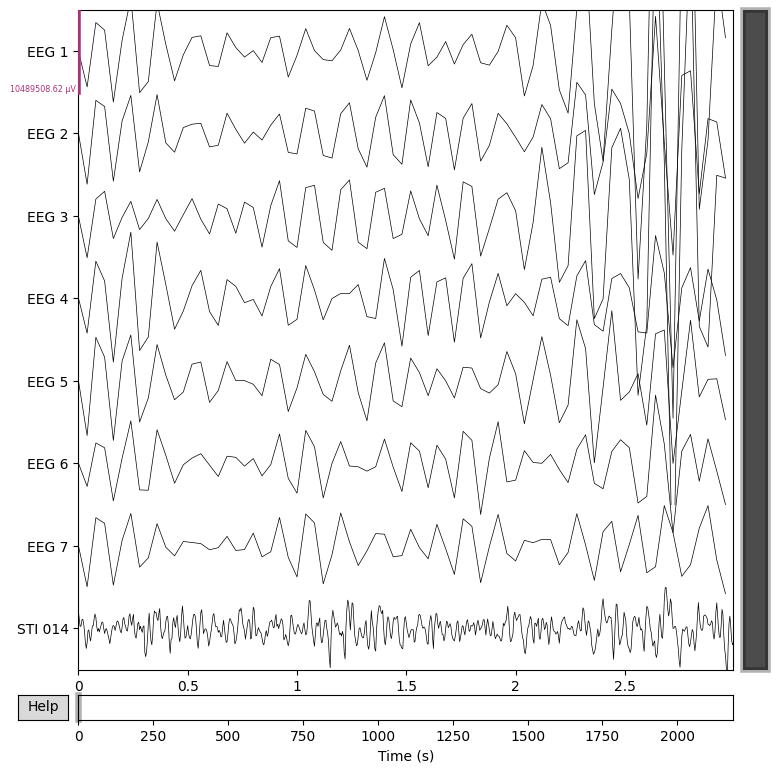

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  second_band_pass.compute_psd().plot()


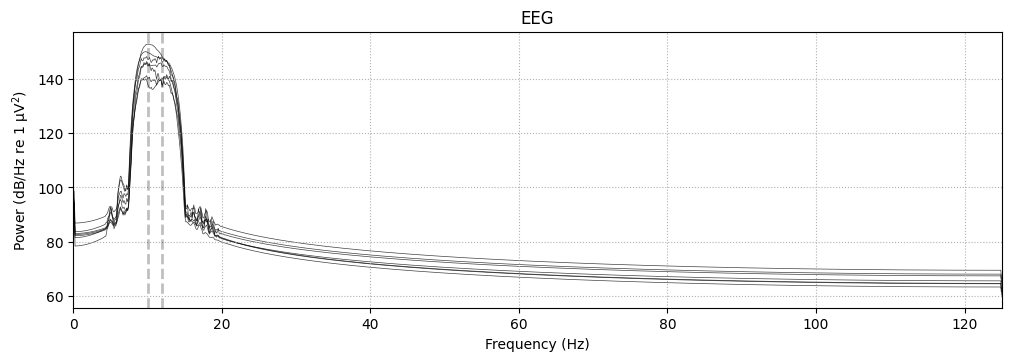

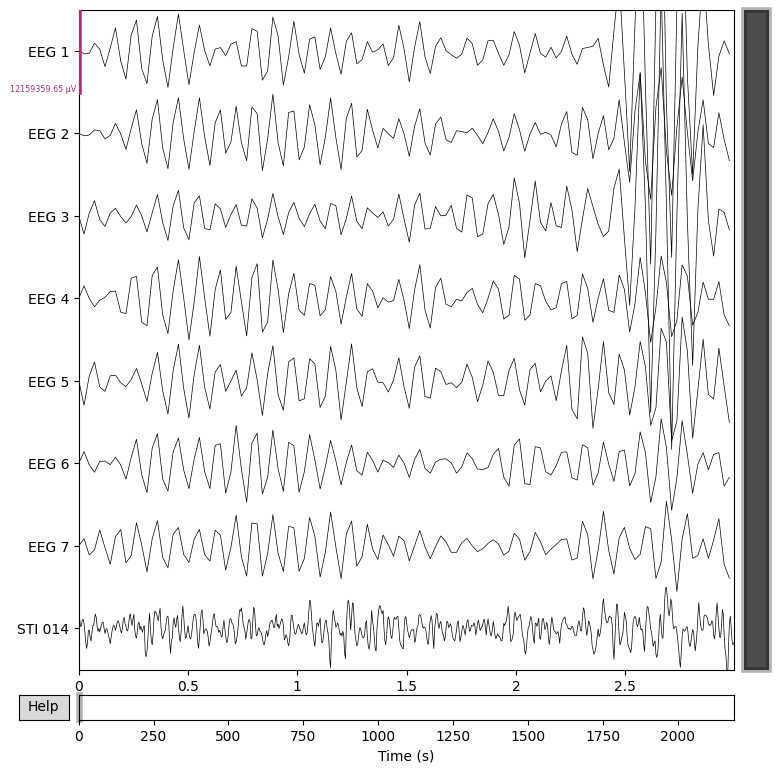

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:18: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  third_band_pass.compute_psd().plot()


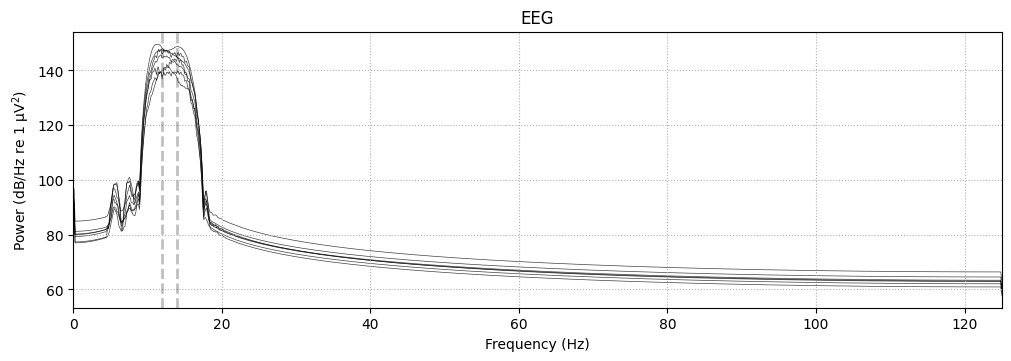

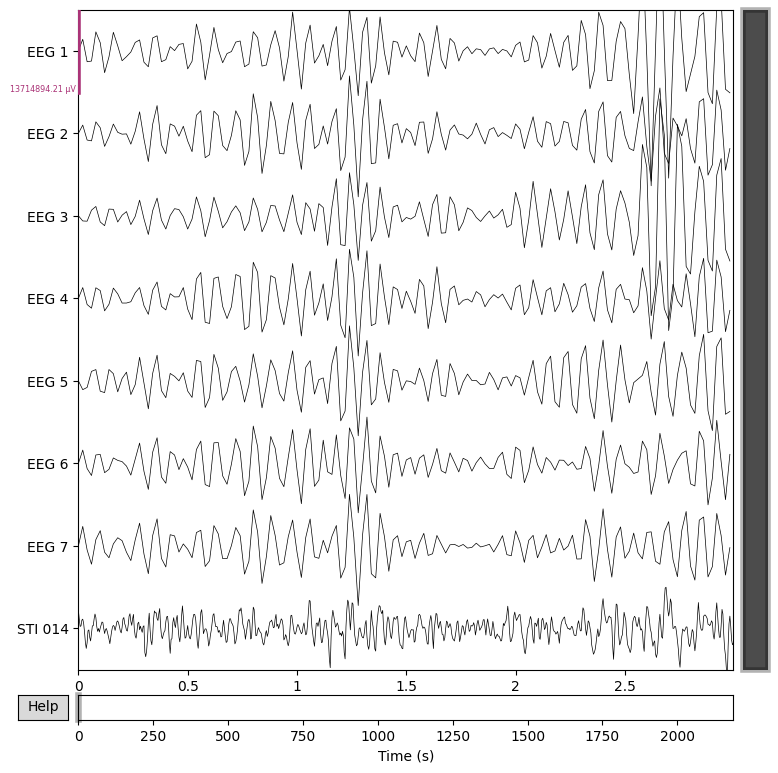

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:22: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fourth_band_pass.compute_psd().plot()


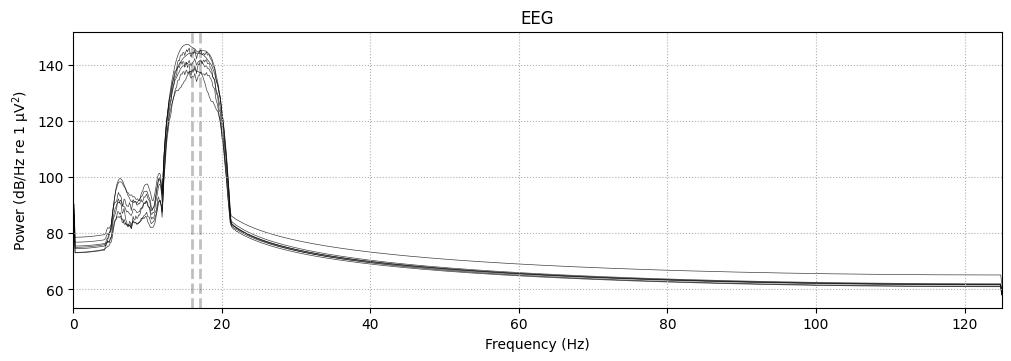

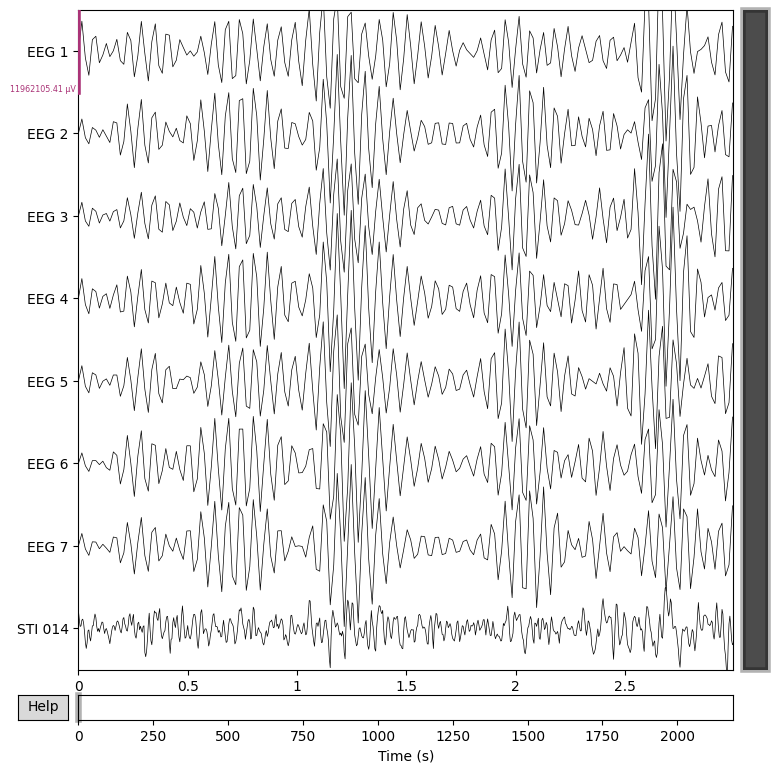

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:26: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  eyes_closed_band_pass.compute_psd().plot()


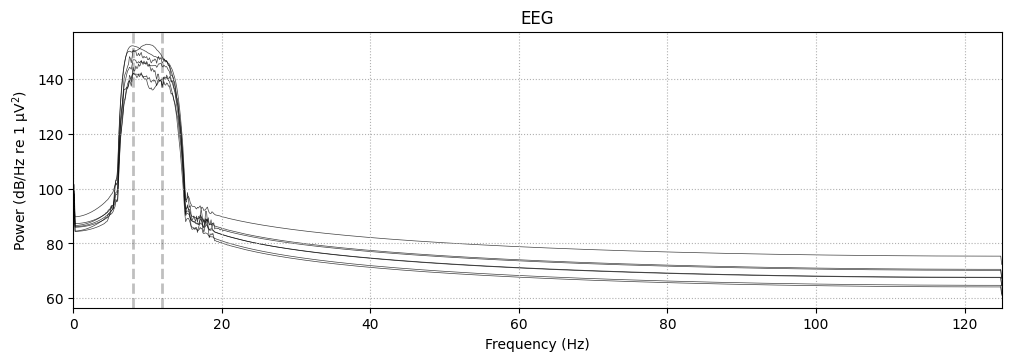

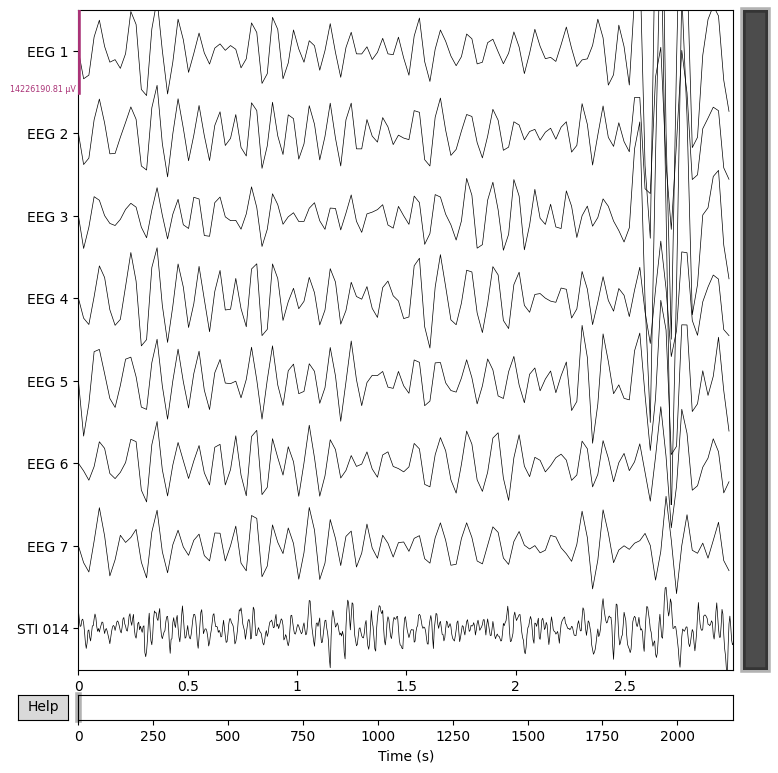

Overwriting existing file.
Writing /content/band_pass_filtered.fif
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:31: RuntimeWarning: This filename (/content/band_pass_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  band_pass_filtered.save('band_pass_filtered.fif', overwrite=True)


Closing /content/band_pass_filtered.fif
[done]
Overwriting existing file.
Writing /content/first_band_pass.fif
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:32: RuntimeWarning: This filename (/content/first_band_pass.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  first_band_pass.save('first_band_pass.fif', overwrite=True)


Closing /content/first_band_pass.fif
[done]
Overwriting existing file.
Writing /content/second_band_pass.fif
Overwriting existing file.


...

/tmp/ipykernel_58785/124497405.py:35: RuntimeWarning: This filename (/content/fourth_band_pass.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  fourth_band_pass.save('fourth_band_pass.fif', overwrite=True)


Closing /content/fourth_band_pass.fif
[done]
Overwriting existing file.
Writing /content/eyes_closed_band_pass.fif
Overwriting existing file.


/tmp/ipykernel_58785/124497405.py:36: RuntimeWarning: This filename (/content/eyes_closed_band_pass.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  eyes_closed_band_pass.save('eyes_closed_band_pass.fif', overwrite=True)


Closing /content/eyes_closed_band_pass.fif
[done]


[PosixPath('/content/eyes_closed_band_pass.fif')]

In [ ]:
# Step 7: Plot the filtered data
# Similar to the raw plot, but now on the filtered version.
# Compare this to the raw plot to see the difference!
duration=3 # duration of the plots
#duation is not needed for psdplots, to plot psd use .compute_psd().plot
band_pass_filtered.compute_psd().plot()
band_pass_filtered.compute_psd().save('band_pass_filtered_psd.h5', overwrite=True)
band_pass_filtered.plot(duration=duration, n_channels=8, title='Filtered EEG Data', scalings='auto', events=None)
plt.show() # Display the first plot
first_band_pass.compute_psd().plot()
first_band_pass.compute_psd().save('first_band_pass_psd.h5', overwrite=True)
first_band_pass.plot(duration=duration, n_channels=8, title='Filtered 7Hz EEG Data', scalings='auto', events=None)
plt.show() # Display the second plot
second_band_pass.compute_psd().plot()
second_band_pass.compute_psd().save('second_band_pass_psd.h5', overwrite=True)
second_band_pass.plot(duration=duration, n_channels=8, title='Filtered 11Hz EEG Data', scalings='auto', events=None)
plt.show() # Display the third plot
third_band_pass.compute_psd().plot()
third_band_pass.compute_psd().save('third_band_pass_psd.h5', overwrite=True)
third_band_pass.plot(duration=duration, n_channels=8, title='Filtered 13Hz EEG Data', scalings='auto', events=None)
plt.show() # Display the fourth plot
fourth_band_pass.compute_psd().plot()
fourth_band_pass.compute_psd().save('fourth_band_pass_psd.h5', overwrite=True)
fourth_band_pass.plot(duration=duration, n_channels=8, title='Filtered 17Hz EEG Data', scalings='auto', events=None)
plt.show() # Display the fifth plot
eyes_closed_band_pass.compute_psd().plot()
eyes_closed_band_pass.compute_psd().save('eyes_closed_band_pass_psd.h5', overwrite=True)
eyes_closed_band_pass.plot(duration=duration, n_channels=8, title='Filtered Eyes Closed EEG Data', scalings='auto', events=None)
plt.show() # Display the sixth plot

band_pass_filtered.save('band_pass_filtered.fif', overwrite=True)
first_band_pass.save('first_band_pass.fif', overwrite=True)
second_band_pass.save('second_band_pass.fif', overwrite=True)
third_band_pass.save('third_band_pass.fif', overwrite=True)
fourth_band_pass.save('fourth_band_pass.fif', overwrite=True)
eyes_closed_band_pass.save('eyes_closed_band_pass.fif', overwrite=True)

# (Optional) Save plots or data if needed
# For example, to save the raw plot as an image:
# fig = raw.plot(duration=10, n_channels=10, show=False)
# fig.savefig('raw_plot.png')
# Do the same for filtered.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
